<a href="https://colab.research.google.com/github/Zeldian-Soul/AI-ML-lab-/blob/main/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

 📊 MODEL PERFORMANCE METRICS
Mean Squared Error (MSE): 40.94
Root Mean Squared Error (RMSE): 6.40
R-squared (R2) Score: 0.6197

 📝 ACTUAL VS PREDICTED (First 10 rows)
     Actual Score  Predicted Score  Difference
521          71.8             77.2        -5.4
737          66.6             73.4        -6.8
740          62.9             73.6       -10.7
660          95.2             91.5         3.7
411          90.2             88.7         1.5
678          63.6             70.7        -7.1
626          96.8             93.4         3.4
513          77.9             74.0         3.9
859          66.5             72.9        -6.4
136          59.7             65.6        -5.9

 ⚖️ MODEL COEFFICIENTS (How much each feature matters)
                               Feature  Coefficient
0                num__study_time_hours     6.013039
6             cat__interne

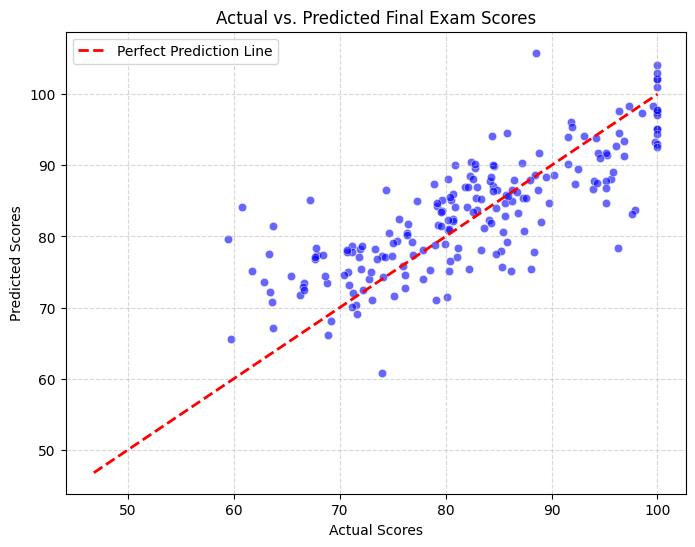

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# 1. Load the cleaned dataset
data = pd.read_csv('/content/drive/My Drive/cleaned_student_performance.csv')

# 2. Define Features (X) and Target (y)
X = data.drop(columns=['student_id', 'final_exam_score', 'final_grade'])
y = data['final_exam_score']

# 3. Group the columns by their type
categorical_cols = ['gender', 'internet_access', 'extracurricular_activities', 'part_time_job']
numerical_cols = ['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade', 'total_productive_hours']

# 4. Build a preprocessor to handle transformations automatically
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])

# 5. Create a Pipeline that chains preprocessing and the regression model together
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# 6. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Train the model
lr_pipeline.fit(X_train, y_train)

# 8. Generate Predictions
y_pred = lr_pipeline.predict(X_test)

# ==========================================
# NEW ADDITIONS: SEEING THE OUTPUTS
# ==========================================

# 9. Evaluate the Model's Performance
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n" + "="*40)
print(" 📊 MODEL PERFORMANCE METRICS")
print("="*40)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")

# 10. Display Actual vs. Predicted Scores (First 10)
print("\n" + "="*40)
print(" 📝 ACTUAL VS PREDICTED (First 10 rows)")
print("="*40)
results_df = pd.DataFrame({'Actual Score': y_test, 'Predicted Score': np.round(y_pred, 1)})
results_df['Difference'] = np.round(results_df['Actual Score'] - results_df['Predicted Score'], 1)
print(results_df.head(10))

# 11. Extract and Display Coefficients (Feature Importance)
print("\n" + "="*40)
print(" ⚖️ MODEL COEFFICIENTS (How much each feature matters)")
print("="*40)
# Extract the trained model and preprocessor from the pipeline
model_step = lr_pipeline.named_steps['model']
preprocessor_step = lr_pipeline.named_steps['preprocessor']

# Get the feature names created by the OneHotEncoder and StandardScaler
feature_names = preprocessor_step.get_feature_names_out()

# Match features with their coefficients
coefficients_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model_step.coef_
}).sort_values(by='Coefficient', ascending=False) # Sort from most positive impact to most negative
print(coefficients_df)

# 12. Visual Output: Actual vs. Predicted Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.6)

# Draw the perfect prediction line (y = x)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')

plt.title('Actual vs. Predicted Final Exam Scores')
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()